In [1]:
# Datos adaptados de: https://www.kaggle.com/competitions/sentiment-analysis-on-movie-reviews/data

import csv

# Ruta a tu archivo de etiquetas
Train_sentiment = 'Train_Sentiment_complete.csv'

# Leer el archivo CSV y convertirlo en una lista de tuplas
data = []
try:
    with open(Train_sentiment, newline='', encoding='utf-8') as csvfile:
        # Usa DictReader con el delimitador correcto
        reader = csv.DictReader(csvfile, delimiter=';')
        for line_num, row in enumerate(reader, start=1):
            phrase = row.get('Phrase')
            sentiment = row.get('Sentiment')
            if phrase and sentiment:
                data.append((phrase, sentiment))
            else:
                print(f"Advertencia: Línea incorrecta en {line_num}: {row}")
except FileNotFoundError as e:
    print("Error: El archivo no fue encontrado.", e)
except csv.Error as e:
    print("Error al leer el archivo CSV:", e)

# Mostrar las primeras filas de la lista de tuplas para verificar que se ha leído correctamente
for i in range(min(5, len(data))):
    print(data[i])

# Mostrar la cantidad total de datos leídos
print()
print(f"Cantidad total de datos leídos: {len(data)}")

('A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .', '1')
('A series of escapades demonstrating the adage that what is good for the goose', '2')
('A series', '2')
('A', '2')
('series', '2')

Cantidad total de datos leídos: 156060


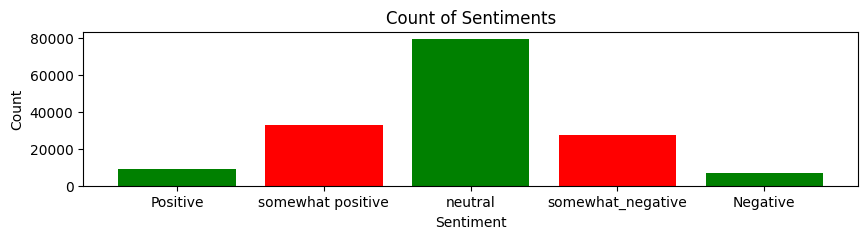

Positive count: 9206
somewhat positive: 32927
neutral count: 79582
somewhat_negative count: 27273
Negative count: 7072


In [2]:
# Contar la cantidad de comentarios positivos y negativos
import matplotlib.pyplot as plt

positive_count = sum(1 for _, label in data if label == "4")
somewhat_positive_count = sum(1 for _, label in data if label == "3")
neutral_count = sum(1 for _, label in data if label == "2")
somewhat_negative_count = sum(1 for _, label in data if label == "1")
negative_count = sum(1 for _, label in data if label == "0")

# Crear la gráfica
labels = ['Positive', 'somewhat positive', 'neutral', 'somewhat_negative','Negative']
counts = [positive_count, somewhat_positive_count, neutral_count, somewhat_negative_count, negative_count]

plt.figure(figsize=(10, 2))  # Ancho 6 pulgadas, Alto 4 pulgadas
plt.bar(labels, counts, color=['green', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Count of Sentiments')
plt.show()
print("Positive count:",positive_count)
print("somewhat positive:",somewhat_positive_count)
print("neutral count:",neutral_count)
print("somewhat_negative count:",somewhat_negative_count)
print("Negative count:",negative_count)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


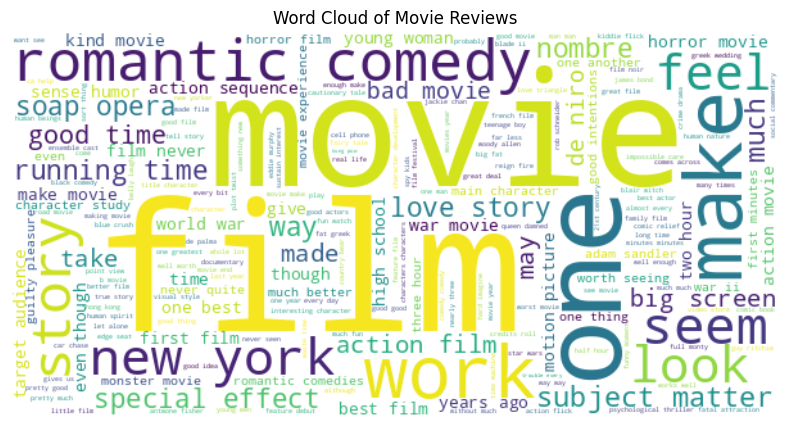

In [3]:
# Muertra la nube de palabras

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')

# Preprocesar los textos
all_words = []
stop_words = set(stopwords.words('english'))

for text, label in data:
    words = word_tokenize(text.lower())  # Tokenizar y convertir a minúsculas
    words = [word for word in words if word.isalnum() and word not in stop_words]  # Eliminar puntuación y stopwords
    all_words.extend(words)

# Crear la nube de palabras
wordcloud = WordCloud(width=600, height=300, background_color='white').generate(' '.join(all_words))

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Reviews')
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


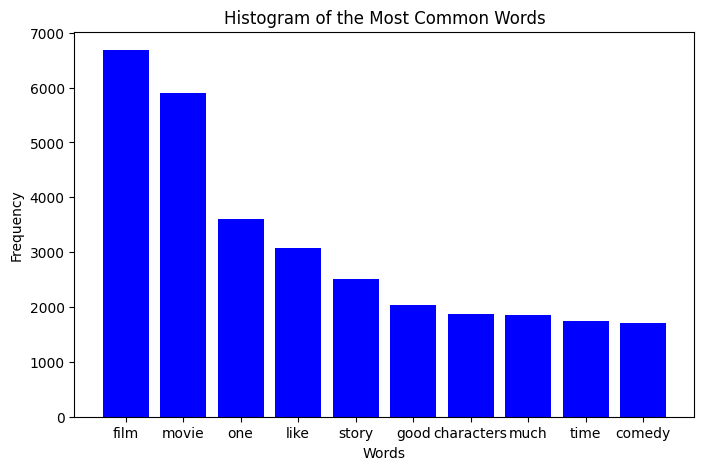

In [5]:
# Muestra el histograma de las palabras

import matplotlib.pyplot as plt
from collections import Counter

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')

# Preprocesar los textos
all_words = []
stop_words = set(stopwords.words('english'))

for text, label in data:
    words = word_tokenize(text.lower())  # Tokenizar y convertir a minúsculas
    words = [word for word in words if word.isalnum() and word not in stop_words]  # Eliminar puntuación y stopwords
    all_words.extend(words)

# Contar la frecuencia de las palabras
word_freq = Counter(all_words)

# Seleccionar las palabras más comunes
common_words = word_freq.most_common(10)

# Crear listas de palabras y sus frecuencias
words = [word for word, freq in common_words]
frequencies = [freq for word, freq in common_words]

# Generar el histograma
plt.figure(figsize=(8, 5))
plt.bar(words, frequencies, color='blue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Histogram of the Most Common Words')
plt.show()

In [7]:
import pandas as pd

# Convertir la lista de tuplas en un DataFrame
df = pd.DataFrame(data, columns=['Phrase', 'Sentiment'])

# Mostrar las primeras filas del DataFrame para verificar
print(df.head())

# Mostrar la cantidad total de datos en el DataFrame
print(f"Cantidad total de datos en el DataFrame: {len(df)}")

                                              Phrase Sentiment
0  A series of escapades demonstrating the adage ...         1
1  A series of escapades demonstrating the adage ...         2
2                                           A series         2
3                                                  A         2
4                                             series         2
Cantidad total de datos en el DataFrame: 156060


In [8]:
#Balancear las clases

import pandas as pd
from sklearn.utils import resample

# Leer el archivo CSV en un DataFrame
#df = pd.read_csv('Train_Sentiment_complete.csv', names=['Phrase', 'Sentiment'])

# Mostrar las primeras filas para confirmar la estructura
print(df.head())

# Verificar la cantidad de datos por clase
class_counts = df['Sentiment'].value_counts()
print("Cantidad de datos por clase antes del balanceo:")
print(class_counts)

# Encontrar la cantidad mínima de datos entre las clases
min_class_count = class_counts.min()

# Balancear el dataset reduciendo todas las clases al tamaño mínimo
df_balanced = pd.DataFrame()

for sentiment in class_counts.index:
    df_class = df[df['Sentiment'] == sentiment]
    df_class_balanced = resample(df_class,
                                 replace=False,    # sin reemplazo
                                 n_samples=min_class_count,    # a la cantidad mínima de la clase
                                 random_state=42)  # para reproducibilidad
    df_balanced = pd.concat([df_balanced, df_class_balanced])

# Verificar la cantidad de datos por clase después del balanceo
balanced_class_counts = df_balanced['Sentiment'].value_counts()
print("\nCantidad de datos por clase después del balanceo:")
print(balanced_class_counts)

# Guardar los datos balanceados en un DataFrame
df_balanced.reset_index(drop=True, inplace=True)

# Mostrar las primeras filas del DataFrame balanceado
print("\nDatos balanceados:")
print(df_balanced.head())

                                              Phrase Sentiment
0  A series of escapades demonstrating the adage ...         1
1  A series of escapades demonstrating the adage ...         2
2                                           A series         2
3                                                  A         2
4                                             series         2
Cantidad de datos por clase antes del balanceo:
Sentiment
2    79582
3    32927
1    27273
4     9206
0     7072
Name: count, dtype: int64

Cantidad de datos por clase después del balanceo:
Sentiment
2    7072
3    7072
1    7072
4    7072
0    7072
Name: count, dtype: int64

Datos balanceados:
                                              Phrase Sentiment
0                  seem pretty unbelievable at times         2
1  smitten document of a troubadour , his acolyte...         2
2             the 1984 uncut version of Sergio Leone         2
3                                    some Westerners         2
4          

In [10]:
#Checking Dataset Description
print(df_balanced.describe())

          Phrase Sentiment
count      35360     35360
unique     35333         5
top     #NOMBRE?         2
freq          28      7072


In [14]:
# Determinar el tipo de datos de cada columna
print(df_balanced.dtypes)

Phrase       object
Sentiment    object
dtype: object


In [15]:
# Crear la lista de frases
review = list(df_balanced['Phrase'])

# Verificar el resultado: Imprimir las primeras 10 frases
print("Primeras 10 frases:")
print(review[:10])

Primeras 10 frases:
['seem pretty unbelievable at times', 'smitten document of a troubadour , his acolytes , and the triumph of his band', 'the 1984 uncut version of Sergio Leone', 'some Westerners', 'Sheds', 'After all', "Performances are potent , and the women 's stories are ably intercut and involving .", 'stiletto-stomps the life', 'a traditional Indian wedding in contemporary New Delhi', 'a change']


In [16]:
# Mostrar los valores únicos en la columna 'Sentiment' para verificar su contenido
print("Valores únicos en 'Sentiment':")
print(df_balanced['Sentiment'].unique())

# Crear etiquetas tal como están en la columna 'Sentiment'
labels = df_balanced['Sentiment'].values

# Verificar el resultado: Imprimir las primeras 10 etiquetas
print("Primeras 10 etiquetas:")
print(labels[:10])

Valores únicos en 'Sentiment':
['2' '3' '1' '4' '0']
Primeras 10 etiquetas:
['2' '2' '2' '2' '2' '2' '2' '2' '2' '2']


In [17]:
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.utils import to_categorical

# División de datos de entrenamiento y prueba
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20, random_state=42)

# Asegurarse de que las etiquetas sean números
train_labels = train_labels.astype(int)
test_labels = test_labels.astype(int)

# Convertir las etiquetas a one-hot encoding para la clasificación multiclase
train_labels = to_categorical(train_labels, num_classes=5)
test_labels = to_categorical(test_labels, num_classes=5)

# Verificar el resultado
print(train_labels[:10])  # Imprime las primeras 10 etiquetas para verificar

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]]


In [18]:
# Mostrar algunos ejemplos del conjunto de entrenamiento

print(f"Review: {train_sentences[:5]}")
print(f"Label: {train_labels[:5]}")

Review: ['a good shot', 'the pitch-perfect Forster to the always hilarious Meara and Levy , Like Mike shoots and scores , doing its namesake proud', 'the perkiness of Witherspoon -LRB- who is always a joy to watch , even when her material is not first-rate -RRB-', 'great yarn', 'Gangster No. 1 is solid , satisfying fare for adults .']
Label: [[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [19]:
# Parámetros de configuración
vocab_size = 10000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [20]:
pip install tensorflow

In [21]:
#tokenización y acolchado de secuencias

import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Inicializar el Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)

# Generar el índice de palabras a partir de las frases de entrenamiento
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index

# Generar y acolchar las secuencias de entrenamiento
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

# Generar y acolchar las secuencias de prueba
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [23]:
# Construcción del modelo

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    LSTM(64, return_sequences=True),  # Primera capa LSTM con return_sequences=True
    LSTM(32),  # Segunda capa LSTM de 32 unidades
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')  # Softmax para clasificación multiclase
])

In [24]:
#Construcción del modelo

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Resumen del modelo
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 104s 110ms/step - accuracy: 0.3058 - loss: 1.5258 - val_accuracy: 0.4757 - val_loss: 1.2486
Epoch 2/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 141s 108ms/step - accuracy: 0.5456 - loss: 1.0929 - val_accuracy: 0.5556 - val_loss: 1.0392
Epoch 3/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 93s 105ms/step - accuracy: 0.6577 - loss: 0.8388 - val_accuracy: 0.5649 - val_loss: 1.0366
Epoch 4/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 143s 107ms/step - accuracy: 0.6919 - loss: 0.7712 - val_accuracy: 0.5605 - val_loss: 1.0415
Epoch 5/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 93s 105ms/step - accuracy: 0.7238 - loss: 0.6879 - val_accuracy: 0.5638 - val_loss: 1.0845
Epoch 6/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 96s 108ms/step - accuracy: 0.7528 - loss: 0.6280 - val_accuracy: 0.5583 - val_loss: 1.1211
Epoch 7/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 141s 107ms/step - accuracy: 0.7677 - loss: 0.5793 - val_accuracy: 0.5583 - val_loss: 1.1942
Epoch 8/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 143s 108ms/step - accuracy: 0.7926 - lo

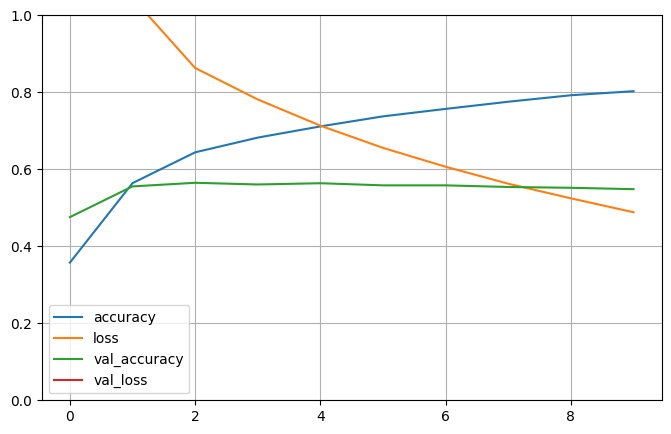

In [25]:
#train the model
import matplotlib.pyplot as plt

num_epochs = 10

history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(test_padded, test_labels))

# Graficar el historial de entrenamiento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()


221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step


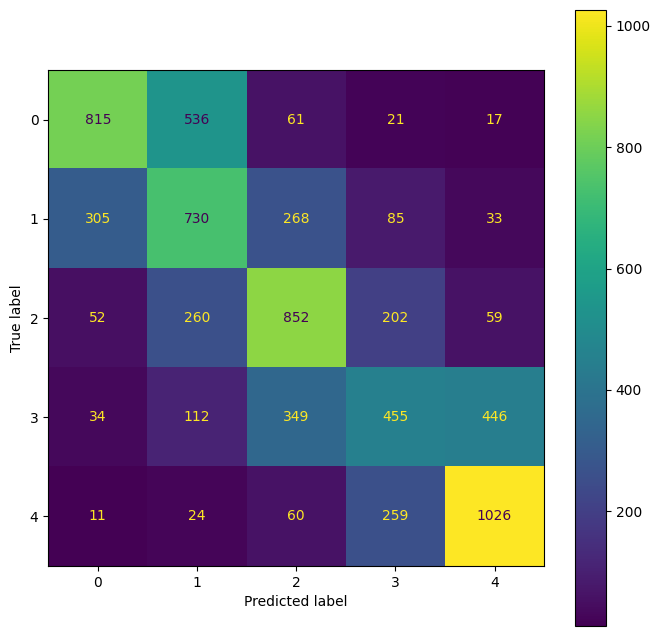

Accuracy: 0.55
F1 Score: 0.54
Accuracy: 0.55
F1 Score: 0.54


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# Obtener las predicciones del modelo sobre el conjunto de prueba
predictions = model.predict(test_padded)

# Para clasificación multiclase, seleccionar la clase con mayor probabilidad
predicted_labels = np.argmax(predictions, axis=1)

# Convertir las etiquetas verdaderas de one-hot encoding a índices de clase
true_labels = np.argmax(test_labels, axis=1)

# Calcular la accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

# Calcular el F1 score con promedio adecuado para multiclase
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Crear la matriz de confusión
cm = confusion_matrix(true_labels, predicted_labels)

# Crear la visualización de la matriz de confusión con etiquetas automáticas
labels = sorted(set(true_labels))  # Extraer etiquetas únicas de true_labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Graficar la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.show()

# Mostrar la accuracy y el F1 score
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")

# Mostrar la accuracy y el F1 score
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")


221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


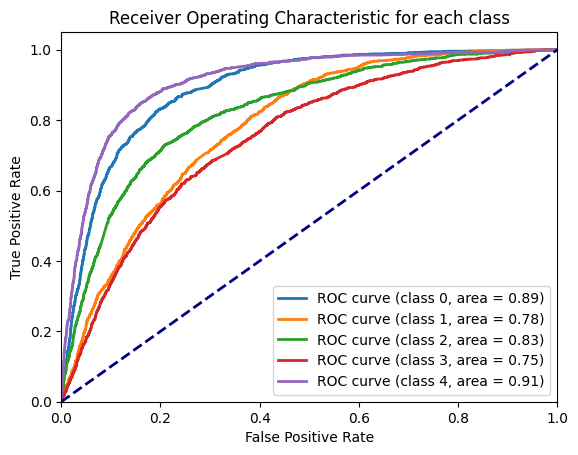

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# test_labels binarizado para cada clase
test_labels_bin = label_binarize(test_labels, classes=[0, 1, 2, 3, 4])

# Obtener las probabilidades de las predicciones para cada clase
y_prob = model.predict(test_padded)

# Graficar la curva ROC para cada clase
plt.figure()
for i in range(test_labels_bin.shape[1]):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (class {i}, area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for each class')
plt.legend(loc='lower right')
plt.show()

221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step


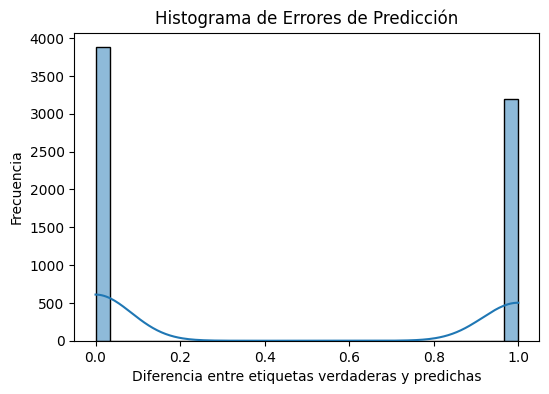

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener las probabilidades de predicción del modelo
y_prob = model.predict(test_padded)

# Obtener la clase con la mayor probabilidad como predicción
y_pred = np.argmax(y_prob, axis=1)

# Convertir las etiquetas verdaderas de one-hot encoding a índices de clase
y_true = np.argmax(test_labels, axis=1)

# Calcular los errores como la diferencia entre las etiquetas verdaderas y las predicciones
errors = y_true != y_pred  # True si incorrecto, False si correcto

# Crear el histograma de errores con barras más delgadas
plt.figure(figsize=(6, 4))
sns.histplot(errors, kde=True, bins=30)
plt.xlabel('Diferencia entre etiquetas verdaderas y predichas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Errores de Predicción')
plt.show()